# EBT 2D Dose Maps: AIC-144 then CCB

This notebook reproduces publication-style 2D dose maps for EBT foils,
following the same visual language as the MBO 2D notebook:
- white-green-red colormap,
- black contour lines with numeric labels,
- profile strip overlay,
- x=0 marker aligned to pencil mark position.

Order of plots:
1. **AIC-144** EBT 2D dose map
2. **CCB** EBT 2D dose map

MC AIC-144 distal 90% point: 24.515 mm
MC CCB     distal 90% point: 26.784 mm
AIC image size: 51.5 x 61.0 mm (304 x 360 px,  px_to_mm=0.1693)
  boundary pixels: 1403,  initial guess: cx=27.91 mm,  cy=30.22 mm,  r=18.10 mm
  pass  1: pts=1403  cx=27.75 mm  cy=30.44 mm  r=18.11 mm  sigma=1.248 mm  thresh=2.496 mm  rejected=408
  pass  2: pts= 995  cx=28.68 mm  cy=30.50 mm  r=18.38 mm  sigma=0.706 mm  thresh=1.413 mm  rejected=224
  pass  3: pts= 771  cx=29.31 mm  cy=30.60 mm  r=18.67 mm  sigma=0.381 mm  thresh=1.000 mm  rejected=74
  pass  4: pts= 697  cx=29.75 mm  cy=30.65 mm  r=18.96 mm  sigma=0.265 mm  thresh=1.000 mm  rejected=18
  pass  5: pts= 679  cx=30.04 mm  cy=30.64 mm  r=19.18 mm  sigma=0.225 mm  thresh=1.000 mm  rejected=13
  pass  6: pts= 666  cx=30.30 mm  cy=30.62 mm  r=19.38 mm  sigma=0.199 mm  thresh=1.000 mm  rejected=11
  pass  7: pts= 655  cx=30.58 mm  cy=30.60 mm  r=19.60 mm  sigma=0.174 mm  thresh=1.000 mm  rejected=9
  pass  8: pts= 646  cx=30.92 mm  cy=30.57 mm  r=

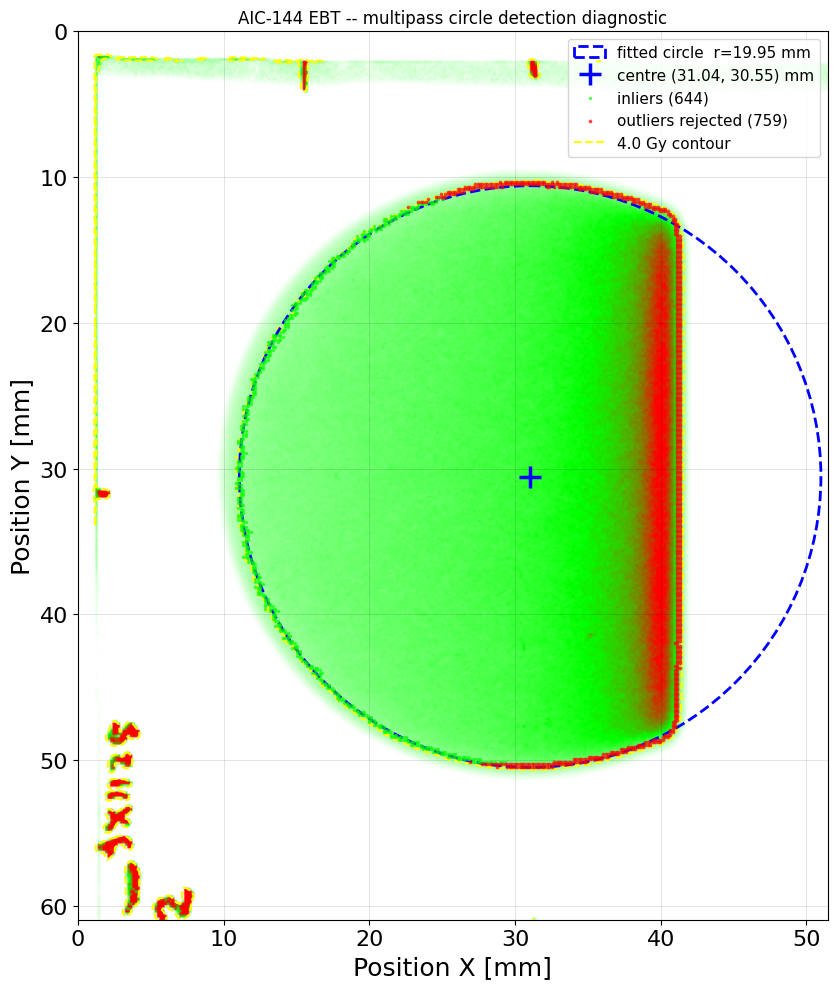

/tmp/ipykernel_58531/467102896.py:124: RuntimeWarning: Mean of empty slice
  prof_raw = np.nanmean(strip, axis=0)


  EBT3 distal 90% (2D, central stripe): x = +9.414 mm
  Wedge start (EBT R90 - MC R90):       x = -15.101 mm


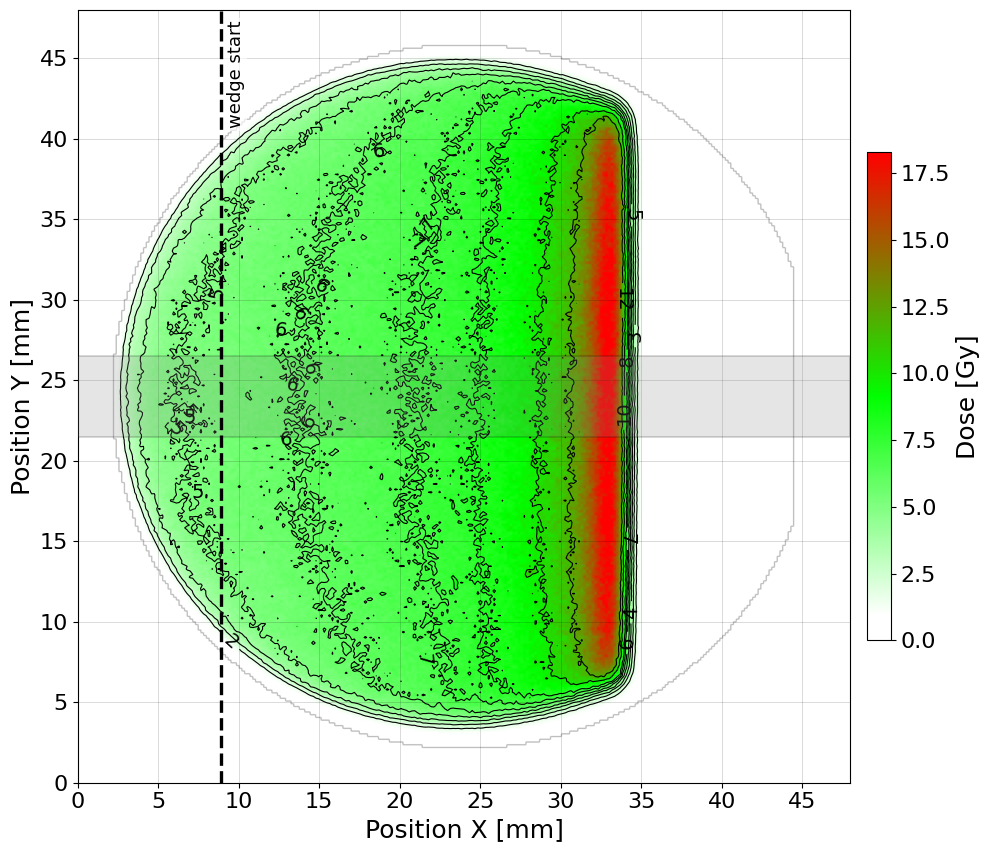

  vmax=18.28 Gy


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import binary_erosion, label as ndi_label
from scipy.optimize import minimize
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, Circle as MplCircle
from matplotlib.ticker import FuncFormatter

# Resolve repository root from current working directory.
repo_root = Path.cwd()
if not (repo_root / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root = parent
            break

# Inputs from EBT processing and comparison configuration.
ebt_root = repo_root / "notebooks" / "pub_something_2026" / "ebt_foils"
aic_npz_path = ebt_root / "ebt_2D_aic144.npz"
ccb_npz_path = ebt_root / "ebt_2D_ccb.npz"

# MC dose profiles used to determine the wedge-start offset
# (same files as in 1.2 / 1.4 notebooks).
mc_root = repo_root / "notebooks" / "pub_something_2026" / "mc"
mc_aic_file = mc_root / "mc_aic144_big.csv"
mc_ccb_file = mc_root / "mc_ccb_big.csv"

for f in (aic_npz_path, ccb_npz_path, mc_aic_file, mc_ccb_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing input file: {f}")

# Parameters matching src/pub2026/ebt/config/comparison.yaml.
DPI = 150.0
PX_TO_MM = 25.4 / DPI
DOSE_THRESHOLD_GY = 4.0   # threshold for circle boundary detection
CIRCLE_RADIUS_EXPECTED_MM = 24.0  # expected radius of irradiated region [mm]
CIRCLE_RADIUS_TOL_MM = 8.0        # +/- tolerance for acceptance warning
CROP_SIZE_MM = 48.0        # total image size [mm] centred on beam
PROFILE_STRIP_WIDTH_MM = 5.0
TICK_STEP_MM = 5.0          # tick spacing for the 2D dose maps

# Multipass circle fitting parameters (analogous to MBO edge refinement).
FIT_N_SIGMA = 2.0
FIT_MIN_DIST_MM = 1.0   # minimum rejection threshold (~6 px at 150 DPI)
FIT_MAX_ITER = 30
FIT_MIN_POINTS = 30     # stop if fewer inliers remain

# Plotting style.
FIGSIZE = (10, 10)
STRIPE_FILL_ALPHA = 0.20
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
CONTOUR_LABEL_FONTSIZE = 14
COLORBAR_LABEL_FONTSIZE = 18
COLORBAR_TICK_FONTSIZE = 16
AIC_CONTOUR_LEVELS = [2, 3, 4, 5, 6, 7, 8, 10, 12]
CCB_CONTOUR_LEVELS = [2, 3, 4, 5, 6, 7, 8, 10, 12]
WEDGE_START_LABEL_Y_MM = -CROP_SIZE_MM / 2 + 4.0


def white_green_red_cmap(white_threshold=0.05):
    return LinearSegmentedColormap.from_list(
        "white_green_red",
        [
            (0.0, (1, 1, 1, 1)),
            (white_threshold, (1, 1, 1, 1)),
            (0.5, (0, 1, 0, 1)),
            (1.0, (1, 0, 0, 1)),
        ],
    )


def load_ebt_2d(npz_path):
    data = np.load(npz_path)
    key = "arr_0" if "arr_0" in data.files else data.files[0]
    return data[key].astype(float)


def distal_falloff_point(x_mm, y, level=0.9):
    """Distal point where *y* drops to *level* (fraction of its peak), via
    linear interpolation between the surrounding samples.
    """
    y = np.asarray(y, dtype=float)
    x_mm = np.asarray(x_mm, dtype=float)
    peak_idx = int(np.nanargmax(y))
    for idx in range(peak_idx + 1, len(y)):
        if y[idx] <= level:
            x0, x1 = x_mm[idx - 1], x_mm[idx]
            y0, y1 = y[idx - 1], y[idx]
            if y1 == y0:
                return float(x1)
            fraction = (level - y0) / (y1 - y0)
            return float(x0 + fraction * (x1 - x0))
    raise ValueError(f"Could not find distal {level:.0%} falloff point.")


def mc_distal_90_from_csv(mc_csv_path):
    """Distal 90 % point of an MC depth-dose CSV (depth in mm, no water-eq scaling)."""
    mc_df = pd.read_csv(mc_csv_path).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})
    mc_df = mc_df[["x_mm", "dose_Gy"]].copy().sort_values("x_mm").reset_index(drop=True)
    y = mc_df["dose_Gy"].to_numpy(dtype=float)
    y_rel = y / np.nanmax(y)
    x = mc_df["x_mm"].to_numpy(dtype=float)
    return distal_falloff_point(x, y_rel, level=0.9)


def ebt_profile_from_centered_strip(dose_cropped, size_mm, strip_width_mm):
    """Average horizontal dose profile across a stripe centred on y=0.

    Returns (x_mm, profile_norm) with x in image-centred coordinates
    [-size_mm/2, +size_mm/2] and profile normalised to its peak value.
    """
    h, w = dose_cropped.shape
    half = size_mm / 2.0
    y_mm = np.linspace(-half, half, h)
    half_strip = strip_width_mm / 2.0
    mask = (y_mm >= -half_strip) & (y_mm <= half_strip)
    if not np.any(mask):
        mask[h // 2] = True
    strip = dose_cropped[mask, :].astype(float)
    prof_raw = np.nanmean(strip, axis=0)
    prof = np.nan_to_num(prof_raw, nan=0.0)
    peak = np.nanmax(prof)
    if peak > 0:
        prof = prof / peak
    x_mm = np.linspace(-half, half, w)
    return x_mm, prof


def _fit_circle(xs_px, ys_px, cx0, cy0, r0):
    def obj(p):
        cx, cy, r = p
        d = np.sqrt((xs_px - cx)**2 + (ys_px - cy)**2)
        return np.sum((d - r)**2)

    res = minimize(obj, x0=[cx0, cy0, r0], method="Nelder-Mead",
                   options={"xatol": 0.05, "fatol": 0.5, "maxiter": 30000})
    return res.x


def detect_beam_circle_mm(dose, px_to_mm, threshold_gy=2.0,
                           n_sigma=FIT_N_SIGMA, min_dist_mm=FIT_MIN_DIST_MM,
                           max_iter=FIT_MAX_ITER, min_points=FIT_MIN_POINTS,
                           verbose=True):
    dose_clean = np.nan_to_num(dose, nan=0.0)
    h, w = dose_clean.shape

    mask = dose_clean > threshold_gy
    if not np.any(mask):
        return w * px_to_mm / 2.0, h * px_to_mm / 2.0, 0.0, [], [], 0

    labeled, n_feat = ndi_label(mask)
    if n_feat > 1:
        sizes = [(labeled == i).sum() for i in range(1, n_feat + 1)]
        largest = np.argmax(sizes) + 1
        mask = labeled == largest

    eroded = binary_erosion(mask, iterations=2)
    boundary = mask & ~eroded
    if not np.any(boundary):
        boundary = mask

    ys_b, xs_b = np.where(boundary)
    xs_px = xs_b.astype(float)
    ys_px = ys_b.astype(float)

    cx0 = float(np.mean(xs_px))
    cy0 = float(np.mean(ys_px))
    r0 = float(np.mean(np.sqrt((xs_px - cx0)**2 + (ys_px - cy0)**2)))
    min_dist_px = min_dist_mm / px_to_mm

    if verbose:
        print(f"  boundary pixels: {len(xs_px)},  initial guess: "
              f"cx={cx0*px_to_mm:.2f} mm,  cy={cy0*px_to_mm:.2f} mm,  "
              f"r={r0*px_to_mm:.2f} mm")

    keep = np.ones(len(xs_px), dtype=bool)
    cx, cy, r = cx0, cy0, r0
    n_iters = 0

    for iteration in range(max_iter):
        n_iters += 1
        xs_k, ys_k = xs_px[keep], ys_px[keep]

        cx, cy, r = _fit_circle(xs_k, ys_k, cx, cy, r)

        dist = np.sqrt((xs_k - cx)**2 + (ys_k - cy)**2)
        residuals = np.abs(dist - r)
        sigma = np.std(residuals)
        thresh_px = max(n_sigma * sigma, min_dist_px)

        new_keep_local = residuals <= thresh_px
        n_rejected = int(np.sum(~new_keep_local))

        if verbose:
            print(f"  pass {iteration + 1:2d}: pts={int(keep.sum()):4d}  "
                  f"cx={cx*px_to_mm:.2f} mm  cy={cy*px_to_mm:.2f} mm  "
                  f"r={r*px_to_mm:.2f} mm  "
                  f"sigma={sigma*px_to_mm:.3f} mm  "
                  f"thresh={thresh_px*px_to_mm:.3f} mm  "
                  f"rejected={n_rejected}")

        if n_rejected == 0:
            if verbose:
                print(f"  converged after {n_iters} passes (no points rejected).")
            break

        keep_indices = np.where(keep)[0]
        keep[keep_indices[~new_keep_local]] = False

        if int(keep.sum()) < min_points:
            if verbose:
                print(f"  stopping: fewer than {min_points} points remain.")
            break
    else:
        if verbose:
            print(f"  reached max_iter={max_iter} without full convergence.")

    xs_k, ys_k = xs_px[keep], ys_px[keep]
    cx, cy, r = _fit_circle(xs_k, ys_k, cx, cy, r)

    kept_pts_mm     = list(zip(xs_k         * px_to_mm, ys_k         * px_to_mm))
    rejected_pts_mm = list(zip(xs_px[~keep] * px_to_mm, ys_px[~keep] * px_to_mm))

    return (cx * px_to_mm, cy * px_to_mm, r * px_to_mm,
            kept_pts_mm, rejected_pts_mm, n_iters)


def crop_dose_to_window(dose, center_x_mm, center_y_mm, px_to_mm, size_mm=44.0):
    h, w = dose.shape
    n = int(round(size_mm / px_to_mm))
    half = n / 2.0

    cx_px = center_x_mm / px_to_mm
    cy_px = center_y_mm / px_to_mm

    x_start = int(round(cx_px - half))
    y_start = int(round(cy_px - half))
    x_end = x_start + n
    y_end = y_start + n

    pad_left   = max(0, -x_start)
    pad_right  = max(0, x_end - w)
    pad_top    = max(0, -y_start)
    pad_bottom = max(0, y_end - h)

    xs = max(0, x_start)
    xe = min(w, x_end)
    ys = max(0, y_start)
    ye = min(h, y_end)

    cropped = dose[ys:ye, xs:xe].copy()

    if pad_left or pad_right or pad_top or pad_bottom:
        cropped = np.pad(
            cropped,
            ((pad_top, pad_bottom), (pad_left, pad_right)),
            mode="constant",
            constant_values=np.nan,
        )
    return cropped


def mask_outside_circle(dose_cropped, max_radius_mm, size_mm):
    """Set pixels farther than *max_radius_mm* from the image centre to np.nan."""
    h, w = dose_cropped.shape
    half = size_mm / 2.0
    y_mm = np.linspace(-half, half, h)
    x_mm = np.linspace(-half, half, w)
    xx, yy = np.meshgrid(x_mm, y_mm)
    dist = np.sqrt(xx**2 + yy**2)
    result = dose_cropped.copy()
    result[dist > max_radius_mm] = np.nan
    return result


def filtered_levels(levels, vmax):
    selected = [lv for lv in levels if 0.0 < lv < vmax]
    if len(selected) >= 2:
        return selected
    return [float(vmax) * 0.25, float(vmax) * 0.5, float(vmax) * 0.75]


def _apply_positive_axis_labels(ax, half, tick_step_mm=TICK_STEP_MM):
    """Relabel ticks so the lower-left corner reads (0 mm, 0 mm) and values
    grow to the right and up. Ticks are placed every *tick_step_mm* in displayed
    coordinates, starting from 0. The image data and all overlays remain at
    their original (image-centred) coordinates -- only the displayed tick
    labels and tick positions change.
    """
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x + half:g}"))
    # In the EBT plot ylim is set to (half, -half), so y=+half is at the
    # bottom of the axes and y=-half at the top. We want the bottom label to
    # read 0 and the top label to read 2*half (= CROP_SIZE_MM).
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{half - y:g}"))

    n_steps = int(np.floor(2 * half / tick_step_mm))
    displayed_ticks_mm = np.arange(0, n_steps * tick_step_mm + 1e-9, tick_step_mm)
    ax.set_xticks(displayed_ticks_mm - half)
    ax.set_yticks(half - displayed_ticks_mm)


def plot_ebt_2d(dose_cropped, contour_levels, title, vmax=None, clip_radius_mm=None,
                wedge_start_x_mm=None):
    """Plot EBT 2D dose map centred on the beam (axes +-CROP_SIZE_MM/2).

    clip_radius_mm: if given, contour lines are geometrically clipped to a
    circle of this radius centred on the origin (beam centre).  Pass the same
    value used for mask_outside_circle so no contours appear outside the foil.

    wedge_start_x_mm: if given, draw a vertical dashed line at this x position
    (in image-centred mm) marking the inferred wedge-start position.
    """
    half = CROP_SIZE_MM / 2.0

    if vmax is None:
        positive = dose_cropped[np.isfinite(dose_cropped) & (dose_cropped > 0)]
        vmax = float(np.percentile(positive, 99.5)) if positive.size else float(np.nanmax(dose_cropped))

    extent = [-half, half, half, -half]
    h, w = dose_cropped.shape
    x_mm = np.linspace(-half, half, w)
    y_mm = np.linspace(-half, half, h)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    im = ax.imshow(
        np.ma.masked_invalid(dose_cropped),
        cmap=white_green_red_cmap(),
        vmin=0.0,
        vmax=vmax,
        extent=extent,
        aspect="equal",
    )

    levels = filtered_levels(contour_levels, vmax)
    # Record how many collections exist before contouring so we can identify
    # the new LineCollections added by ax.contour (cs.collections was removed
    # in matplotlib >= 3.8).
    n_coll_before = len(ax.collections)
    cs = ax.contour(x_mm, y_mm, np.nan_to_num(dose_cropped, nan=0.0), levels=levels,
                    colors="black", linewidths=0.8)

    # Clip contour lines to the detector circle so nothing is drawn outside.
    if clip_radius_mm is not None:
        clip_patch = MplCircle((0, 0), clip_radius_mm, transform=ax.transData)
        for coll in ax.collections[n_coll_before:]:
            coll.set_clip_path(clip_patch)

    ax.clabel(cs, inline=True, fontsize=CONTOUR_LABEL_FONTSIZE, fmt="%.0f")

    half_strip = PROFILE_STRIP_WIDTH_MM / 2.0
    strip = Rectangle((-half, -half_strip), CROP_SIZE_MM, PROFILE_STRIP_WIDTH_MM,
                      facecolor="gray", edgecolor="black", linewidth=1.1,
                      alpha=STRIPE_FILL_ALPHA, zorder=6)
    ax.add_patch(strip)

    # ax.axvline(0.0, color="black", linestyle="-", linewidth=1.4, zorder=7)
    # ax.axhline(0.0, color="black", linestyle="-", linewidth=1.4, zorder=7)

    if wedge_start_x_mm is not None:
        ax.axvline(
            wedge_start_x_mm,
            color="black",
            linestyle="--",
            linewidth=2.4,
            zorder=7,
        )
        ax.text(
            wedge_start_x_mm + 0.35,
            WEDGE_START_LABEL_Y_MM,
            "wedge start",
            rotation=90,
            va="center",
            ha="left",
            fontsize=13,
            color="black",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 2.0},
            zorder=8,
        )

    ax.set_xlim(-half, half)
    ax.set_ylim(half, -half)
    # ax.set_title(title)
    ax.set_xlabel("Position X [mm]", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Position Y [mm]", fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.grid(True, color="k", alpha=0.2, lw=0.5)

    # Show only positive coordinates with (0, 0) in the lower-left corner;
    # image data and overlays are left untouched.
    _apply_positive_axis_labels(ax, half)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Dose [Gy]", fontsize=COLORBAR_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)

    fig.tight_layout()
    return fig


def plot_circle_diagnostic(dose, center_x_mm, center_y_mm, radius_mm,
                           kept_pts_mm, rejected_pts_mm, px_to_mm, title,
                           vmax=None):
    h, w = dose.shape
    if vmax is None:
        positive = dose[np.isfinite(dose) & (dose > 0)]
        vmax = float(np.percentile(positive, 99.5)) if positive.size else float(np.nanmax(dose))

    extent_full = [0, w * px_to_mm, h * px_to_mm, 0]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.imshow(
        np.ma.masked_invalid(dose),
        cmap=white_green_red_cmap(),
        vmin=0.0,
        vmax=vmax,
        extent=extent_full,
        aspect="equal",
    )

    circle_patch = MplCircle(
        (center_x_mm, center_y_mm), radius_mm,
        color="blue", fill=False, linewidth=2.0, linestyle="--", zorder=8,
        label=f"fitted circle  r={radius_mm:.2f} mm",
    )
    ax.add_patch(circle_patch)
    ax.plot(center_x_mm, center_y_mm, "b+", ms=16, mew=2.5, zorder=9,
            label=f"centre ({center_x_mm:.2f}, {center_y_mm:.2f}) mm")

    if kept_pts_mm:
        ex = [p[0] for p in kept_pts_mm]
        ey = [p[1] for p in kept_pts_mm]
        ax.scatter(ex, ey, s=2, c="lime", alpha=0.6, zorder=10,
                   label=f"inliers ({len(kept_pts_mm)})")

    if rejected_pts_mm:
        ex = [p[0] for p in rejected_pts_mm]
        ey = [p[1] for p in rejected_pts_mm]
        ax.scatter(ex, ey, s=3, c="red", alpha=0.6, zorder=11,
                   label=f"outliers rejected ({len(rejected_pts_mm)})")

    dose_clean = np.nan_to_num(dose, nan=0.0)
    xg = np.linspace(0, w * px_to_mm, w)
    yg = np.linspace(0, h * px_to_mm, h)
    ax.contour(xg, yg, dose_clean, levels=[DOSE_THRESHOLD_GY],
               colors="yellow", linewidths=1.5, linestyles="--", zorder=7)
    ax.plot([], [], color="yellow", linestyle="--", linewidth=1.5,
            label=f"{DOSE_THRESHOLD_GY} Gy contour")

    ax.set_title(title)
    ax.set_xlabel("Position X [mm]", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Position Y [mm]", fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.legend(loc="upper right", fontsize=11)
    ax.grid(True, color="k", alpha=0.15, lw=0.5)

    fig.tight_layout()
    return fig


# Distal 90% points from exact MC simulations used in 1D notebooks
# (depth in mm in the wedge frame, where depth=0 is the wedge entrance).
mc_aic_r90_mm = mc_distal_90_from_csv(mc_aic_file)
mc_ccb_r90_mm = mc_distal_90_from_csv(mc_ccb_file)
print(f"MC AIC-144 distal 90% point: {mc_aic_r90_mm:.3f} mm")
print(f"MC CCB     distal 90% point: {mc_ccb_r90_mm:.3f} mm")


# ------------------------------------------------------------------
# 1) AIC-144 EBT
# ------------------------------------------------------------------
aic_dose = load_ebt_2d(aic_npz_path)
print(f"AIC image size: {aic_dose.shape[1] * PX_TO_MM:.1f} x {aic_dose.shape[0] * PX_TO_MM:.1f} mm "
      f"({aic_dose.shape[1]} x {aic_dose.shape[0]} px,  px_to_mm={PX_TO_MM:.4f})")

(aic_center_x_mm, aic_center_y_mm, aic_radius_mm,
 aic_kept_pts_mm, aic_rejected_pts_mm, aic_n_iters) = detect_beam_circle_mm(
    aic_dose, PX_TO_MM, threshold_gy=DOSE_THRESHOLD_GY)

r_ok = abs(aic_radius_mm - CIRCLE_RADIUS_EXPECTED_MM) <= CIRCLE_RADIUS_TOL_MM
print(f"  FINAL: centre=({aic_center_x_mm:.2f}, {aic_center_y_mm:.2f}) mm,  "
      f"r={aic_radius_mm:.2f} mm  "
      f"{'OK' if r_ok else f'*** CHECK -- expected ~{CIRCLE_RADIUS_EXPECTED_MM} mm ***'}")
print(f"  inliers={len(aic_kept_pts_mm)},  outliers={len(aic_rejected_pts_mm)},  passes={aic_n_iters}")

fig_aic_diag = plot_circle_diagnostic(
    aic_dose, aic_center_x_mm, aic_center_y_mm, aic_radius_mm,
    aic_kept_pts_mm, aic_rejected_pts_mm, PX_TO_MM,
    title="AIC-144 EBT -- multipass circle detection diagnostic",
)
plt.show()

aic_dose_cropped = crop_dose_to_window(aic_dose, aic_center_x_mm, aic_center_y_mm, PX_TO_MM, CROP_SIZE_MM)
aic_dose_cropped = mask_outside_circle(aic_dose_cropped, aic_radius_mm + 2.0, CROP_SIZE_MM)
aic_vmax = float(np.percentile(aic_dose_cropped[np.isfinite(aic_dose_cropped) & (aic_dose_cropped > 0)], 99.5))

# Distal 90 % point of the EBT3 profile extracted from the central horizontal
# stripe of the centred 2D dose map; wedge start is mc_R90 mm proximal to it.
aic_profile_x_mm, aic_profile_y = ebt_profile_from_centered_strip(
    aic_dose_cropped, CROP_SIZE_MM, PROFILE_STRIP_WIDTH_MM)
aic_ebt_r90_mm = distal_falloff_point(aic_profile_x_mm, aic_profile_y, level=0.9)
aic_wedge_start_x_mm = aic_ebt_r90_mm - mc_aic_r90_mm
print(f"  EBT3 distal 90% (2D, central stripe): x = {aic_ebt_r90_mm:+.3f} mm")
print(f"  Wedge start (EBT R90 - MC R90):       x = {aic_wedge_start_x_mm:+.3f} mm")

fig_aic = plot_ebt_2d(
    aic_dose_cropped, AIC_CONTOUR_LEVELS, title="AIC-144 EBT 2D Dose", vmax=aic_vmax,
    clip_radius_mm=aic_radius_mm + 2.0,
    wedge_start_x_mm=aic_wedge_start_x_mm)
plt.show()
print(f"  vmax={aic_vmax:.2f} Gy")


CCB image size: 44.7 x 50.5 mm (264 x 298 px,  px_to_mm=0.1693)
  boundary pixels: 1439,  initial guess: cx=24.08 mm,  cy=24.99 mm,  r=19.56 mm
  pass  1: pts=1439  cx=23.90 mm  cy=24.99 mm  r=19.56 mm  sigma=0.900 mm  thresh=1.799 mm  rejected=346
  pass  2: pts=1093  cx=24.61 mm  cy=24.98 mm  r=19.87 mm  sigma=0.499 mm  thresh=1.000 mm  rejected=135
  pass  3: pts= 958  cx=25.14 mm  cy=24.97 mm  r=20.17 mm  sigma=0.252 mm  thresh=1.000 mm  rejected=29
  pass  4: pts= 929  cx=25.35 mm  cy=24.97 mm  r=20.31 mm  sigma=0.164 mm  thresh=1.000 mm  rejected=10
  pass  5: pts= 919  cx=25.41 mm  cy=24.97 mm  r=20.35 mm  sigma=0.135 mm  thresh=1.000 mm  rejected=2
  pass  6: pts= 917  cx=25.43 mm  cy=24.97 mm  r=20.36 mm  sigma=0.129 mm  thresh=1.000 mm  rejected=3
  pass  7: pts= 914  cx=25.45 mm  cy=24.98 mm  r=20.37 mm  sigma=0.122 mm  thresh=1.000 mm  rejected=1
  pass  8: pts= 913  cx=25.45 mm  cy=24.97 mm  r=20.38 mm  sigma=0.119 mm  thresh=1.000 mm  rejected=0
  converged after 8 passes

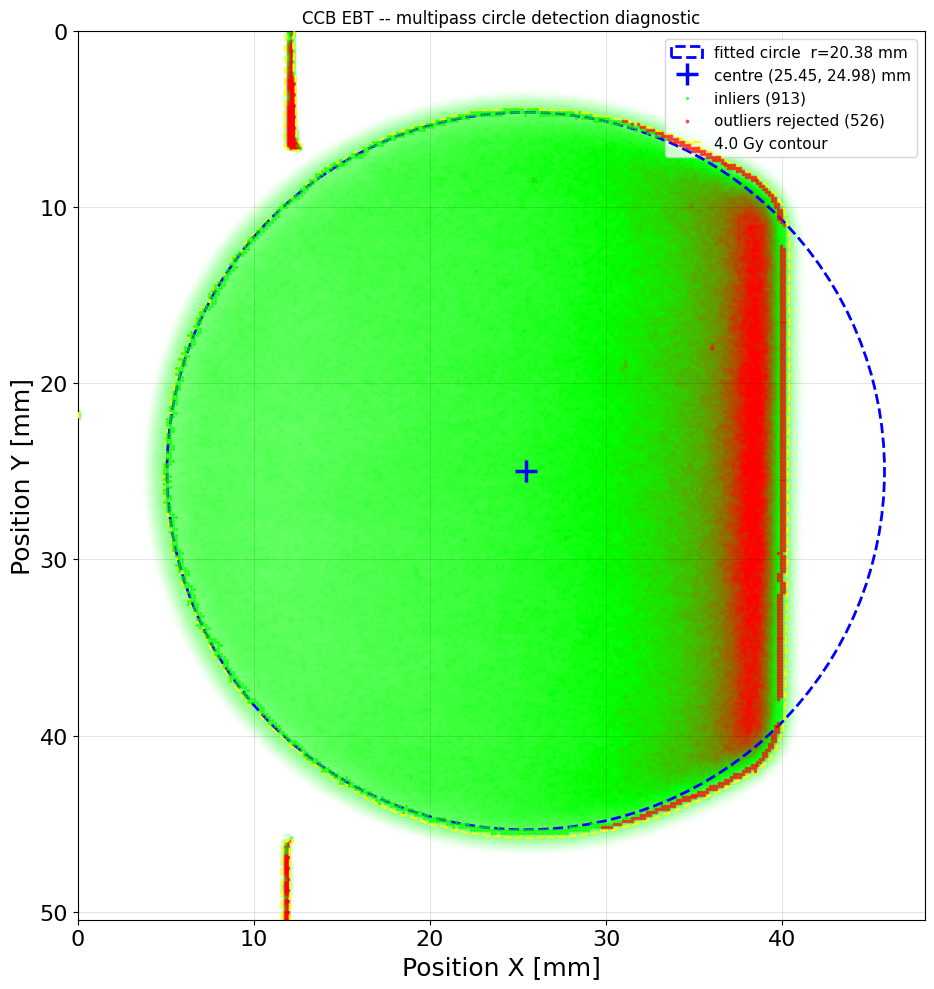

/tmp/ipykernel_58531/467102896.py:124: RuntimeWarning: Mean of empty slice
  prof_raw = np.nanmean(strip, axis=0)


  EBT3 distal 90% (2D, central stripe): x = +13.526 mm
  Wedge start (EBT R90 - MC R90):       x = -13.258 mm


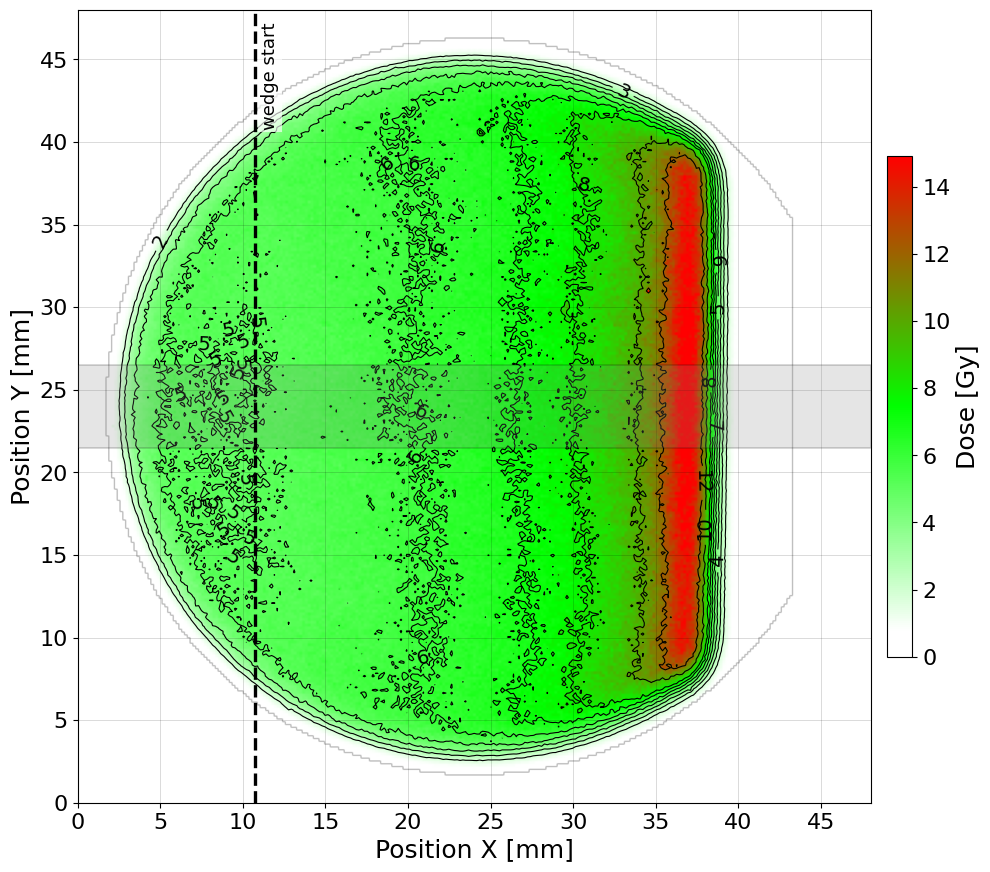

  vmax=14.93 Gy


In [13]:
# ------------------------------------------------------------------
# 2) CCB EBT
# ------------------------------------------------------------------
ccb_dose = load_ebt_2d(ccb_npz_path)
print(f"CCB image size: {ccb_dose.shape[1] * PX_TO_MM:.1f} x {ccb_dose.shape[0] * PX_TO_MM:.1f} mm "
      f"({ccb_dose.shape[1]} x {ccb_dose.shape[0]} px,  px_to_mm={PX_TO_MM:.4f})")

(ccb_center_x_mm, ccb_center_y_mm, ccb_radius_mm,
 ccb_kept_pts_mm, ccb_rejected_pts_mm, ccb_n_iters) = detect_beam_circle_mm(
    ccb_dose, PX_TO_MM, threshold_gy=DOSE_THRESHOLD_GY,
    n_sigma=FIT_N_SIGMA, max_iter=FIT_MAX_ITER, min_points=FIT_MIN_POINTS)

r_ok = abs(ccb_radius_mm - CIRCLE_RADIUS_EXPECTED_MM) <= CIRCLE_RADIUS_TOL_MM
print(f"  FINAL: centre=({ccb_center_x_mm:.2f}, {ccb_center_y_mm:.2f}) mm,  "
      f"r={ccb_radius_mm:.2f} mm  "
      f"{'OK' if r_ok else f'*** CHECK -- expected ~{CIRCLE_RADIUS_EXPECTED_MM} mm ***'}")
print(f"  inliers={len(ccb_kept_pts_mm)},  outliers={len(ccb_rejected_pts_mm)},  passes={ccb_n_iters}")

fig_ccb_diag = plot_circle_diagnostic(
    ccb_dose, ccb_center_x_mm, ccb_center_y_mm, ccb_radius_mm,
    ccb_kept_pts_mm, ccb_rejected_pts_mm, PX_TO_MM,
    title="CCB EBT -- multipass circle detection diagnostic",
)
plt.show()

ccb_dose_cropped = crop_dose_to_window(ccb_dose, ccb_center_x_mm, ccb_center_y_mm, PX_TO_MM, CROP_SIZE_MM)
ccb_dose_cropped = mask_outside_circle(ccb_dose_cropped, ccb_radius_mm + 2.0, CROP_SIZE_MM)
ccb_vmax = float(np.percentile(ccb_dose_cropped[np.isfinite(ccb_dose_cropped) & (ccb_dose_cropped > 0)], 99.5))

# Distal 90 % point of the EBT3 profile extracted from the central horizontal
# stripe of the centred 2D dose map; wedge start is mc_R90 mm proximal to it.
ccb_profile_x_mm, ccb_profile_y = ebt_profile_from_centered_strip(
    ccb_dose_cropped, CROP_SIZE_MM, PROFILE_STRIP_WIDTH_MM)
ccb_ebt_r90_mm = distal_falloff_point(ccb_profile_x_mm, ccb_profile_y, level=0.9)
ccb_wedge_start_x_mm = ccb_ebt_r90_mm - mc_ccb_r90_mm
print(f"  EBT3 distal 90% (2D, central stripe): x = {ccb_ebt_r90_mm:+.3f} mm")
print(f"  Wedge start (EBT R90 - MC R90):       x = {ccb_wedge_start_x_mm:+.3f} mm")

fig_ccb = plot_ebt_2d(
    ccb_dose_cropped, CCB_CONTOUR_LEVELS, title="CCB EBT 2D Dose", vmax=ccb_vmax,
    clip_radius_mm=ccb_radius_mm + 2.0,
    wedge_start_x_mm=ccb_wedge_start_x_mm)
plt.show()
print(f"  vmax={ccb_vmax:.2f} Gy")
